============================================================
 ### LAB03 - Tarefa v
 Comparação dos métodos hierárquicos:
 single, complete e ward
 Determinação do número de clusters pelo método de Mojena
 ============================================================

In [1]:
# ------------------------------------------------------------
# 1. Importação das bibliotecas
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering


In [3]:
# ------------------------------------------------------------
# 2. Leitura da base de dados
# Ajuste o caminho conforme o local do seu arquivo
# ------------------------------------------------------------
dados = pd.read_csv('DadosWH.csv')

print("Primeiras linhas da base:")
print(dados.head())

print("\nColunas da base:")
print(dados.columns.tolist())

print("\nDimensão da base:")
print(dados.shape)


Primeiras linhas da base:
          Name Continent  year  population  Life_Ladder  Log_GDP_per_capita  \
0  Afghanistan      Asia  2010  29185507.0        4.758               7.647   
1  Afghanistan      Asia  2011  30117413.0        3.832               7.620   
2  Afghanistan      Asia  2012  31161376.0        3.783               7.705   
3  Afghanistan      Asia  2013  32269589.0        3.572               7.725   
4  Afghanistan      Asia  2014  33370794.0        3.131               7.718   

   Social_support  Healthy_life_expectancy_at_birth  \
0           0.539                             51.60   
1           0.521                             51.92   
2           0.521                             52.24   
3           0.484                             52.56   
4           0.526                             52.88   

   Freedom_to_make_life_choices  Generosity  Perceptions_of_corruption  \
0                         0.600       0.121                      0.707   
1                   

In [4]:
# ------------------------------------------------------------
# 3. Filtra somente o ano de 2019
# ------------------------------------------------------------
dados2019 = dados[dados['year'] == 2019].copy()

print("\nDimensão da base filtrada para 2019:")
print(dados2019.shape)


Dimensão da base filtrada para 2019:
(122, 13)


In [5]:
# ------------------------------------------------------------
# 4. Seleciona as duas dimensões utilizadas na tarefa iv
# conforme o arquivo Lab03Tarefa04
# ------------------------------------------------------------
dimensoes = ['Life_Ladder', 'Perceptions_of_corruption']

Xs = dados2019[dimensoes].copy()

# normalização min-max
Xs = (Xs - Xs.min()) / (Xs.max() - Xs.min())

# usa o nome do país como índice
Xs.index = dados2019['Name']

print("\nPrimeiras linhas da matriz Xs normalizada:")
print(Xs.head())

# versão numérica para os algoritmos
Xs_numeric = Xs.values


Primeiras linhas da matriz Xs normalizada:
             Life_Ladder  Perceptions_of_corruption
Name                                               
Afghanistan     0.000000                   0.956327
Albania         0.484736                   0.945129
Algeria         0.438483                   0.751400
Argentina       0.686586                   0.851064
Armenia         0.575948                   0.574468


In [6]:
# ------------------------------------------------------------
# 5. Função para plotar o dendrograma
# ------------------------------------------------------------
def plotar_dendrograma(X, labels, metodo):
    plt.figure(figsize=(20, 8))
    dendrogram(
        linkage(X, method=metodo),
        labels=labels,
        leaf_rotation=90
    )
    plt.title(f'Dendrograma - Método {metodo}', fontsize=16)
    plt.xlabel('Países', fontsize=12)
    plt.ylabel('Distância', fontsize=12)
    plt.tight_layout()
    plt.show()

In [11]:
def mojena_num_clusters(Z, c=1.25):
    """
    Esta função estima o número ótimo de clusters pelo método de Mojena.

    Parâmetros:
    Z -> matriz linkage gerada pelo scipy
    c -> constante usada na regra de Mojena

    Retorna:
    k_otimo -> número estimado de clusters
    corte -> distância de corte no dendrograma
    indice_salto -> posição da primeira quebra significativa
    """

    # Z[:, 2] pega a terceira coluna da matriz Z
    # Essa coluna guarda as distâncias de fusão entre clusters
    distancias = Z[:, 2]

    # Se há n observações, a matriz Z tem n-1 linhas
    # então recuperamos o número de observações originais com:
    n = Z.shape[0] + 1

    # vamos percorrer as distâncias de fusão
    # começando de i = 1 porque precisamos olhar o histórico anterior
    for i in range(1, len(distancias)):

        # média das distâncias anteriores à posição i
        media_prev = np.mean(distancias[:i])

        # desvio padrão das distâncias anteriores
        # ddof=1 calcula o desvio amostral
        # se i == 1, ainda não faz sentido calcular desvio,
        # então colocamos 0.0
        if i > 1:
            desvio_prev = np.std(distancias[:i], ddof=1)
        else:
            desvio_prev = 0.0

        # regra de Mojena:
        # identifica quebra quando a distância atual ultrapassa
        # média + c * desvio
        limite = media_prev + c * desvio_prev

        # se a distância atual passar desse limite,
        # consideramos que houve uma quebra importante
        if distancias[i] > limite:

            # o número de clusters antes dessa fusão é:
            # n - i
            k_otimo = n - i

            # guardamos também a distância de corte
            corte = distancias[i]

            # posição onde a quebra foi detectada
            indice_salto = i

            return k_otimo, corte, indice_salto

    # se não houver quebra clara,
    # por segurança devolvemos 2 clusters
    return 2, distancias[-1], len(distancias) - 1

In [13]:
# ------------------------------------------------------------
# 7. Função para executar cada método e resumir os resultados
# ------------------------------------------------------------
def analisar_metodo(X, labels, metodo, c_mojena=1.25):
    print("\n" + "="*60)
    print(f"MÉTODO: {metodo.upper()}")
    print("="*60)

    # linkage
    Z = linkage(X, method=metodo)

    # Mojena
    k_otimo, corte, indice_salto = mojena_num_clusters(Z, c=c_mojena)

    print(f"Número ótimo de clusters pelo método de Mojena: {k_otimo}")
    print(f"Distância de corte estimada: {corte:.4f}")
    print(f"Índice da quebra detectada: {indice_salto}")

    # clusters pelo scipy
    grupos = fcluster(Z, t=k_otimo, criterion='maxclust')

    # organiza saída em DataFrame
    resultado = pd.DataFrame({
        'País': labels,
        'Cluster': grupos
    }).sort_values(by='Cluster')

    print("\nDistribuição de países por cluster:")
    print(resultado)

    print("\nQuantidade de países em cada cluster:")
    print(resultado['Cluster'].value_counts().sort_index())

    # dendrograma
    plt.figure(figsize=(20, 8))
    dendrogram(
        Z,
        labels=labels,
        leaf_rotation=90,
        color_threshold=corte
    )
    plt.axhline(y=corte, color='red', linestyle='--', label=f'Corte Mojena = {corte:.4f}')
    plt.title(f'Dendrograma - Método {metodo}', fontsize=16)
    plt.xlabel('Países', fontsize=12)
    plt.ylabel('Distância', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # gráfico dos pontos coloridos pelos clusters
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=grupos, s=60)
    plt.title(f'Agrupamento - Método {metodo}', fontsize=14)
    plt.xlabel('Life_Ladder (normalizado)')
    plt.ylabel('Perceptions_of_corruption (normalizado)')

    for i, nome in enumerate(labels):
        plt.annotate(nome, (X[i, 0], X[i, 1]), fontsize=7, alpha=0.7)

    plt.tight_layout()
    plt.show()

    return {
        'metodo': metodo,
        'k_otimo': k_otimo,
        'corte': corte,
        'resultado': resultado,
        'grupos': grupos,
        'Z': Z
    }


MÉTODO: SINGLE
Número ótimo de clusters pelo método de Mojena: 121
Distância de corte estimada: 0.0083
Índice da quebra detectada: 1

Distribuição de países por cluster:
            País  Cluster
30       Denmark        1
36       Finland        2
7     Azerbaijan        3
105   Tajikistan        4
37        France        5
..           ...      ...
106     Tanzania      117
121     Zimbabwe      118
0    Afghanistan      119
98     Singapore      120
93        Rwanda      121

[122 rows x 2 columns]

Quantidade de países em cada cluster:
Cluster
1      1
2      1
3      1
4      1
5      1
      ..
117    1
118    1
119    1
120    1
121    1
Name: count, Length: 121, dtype: int64


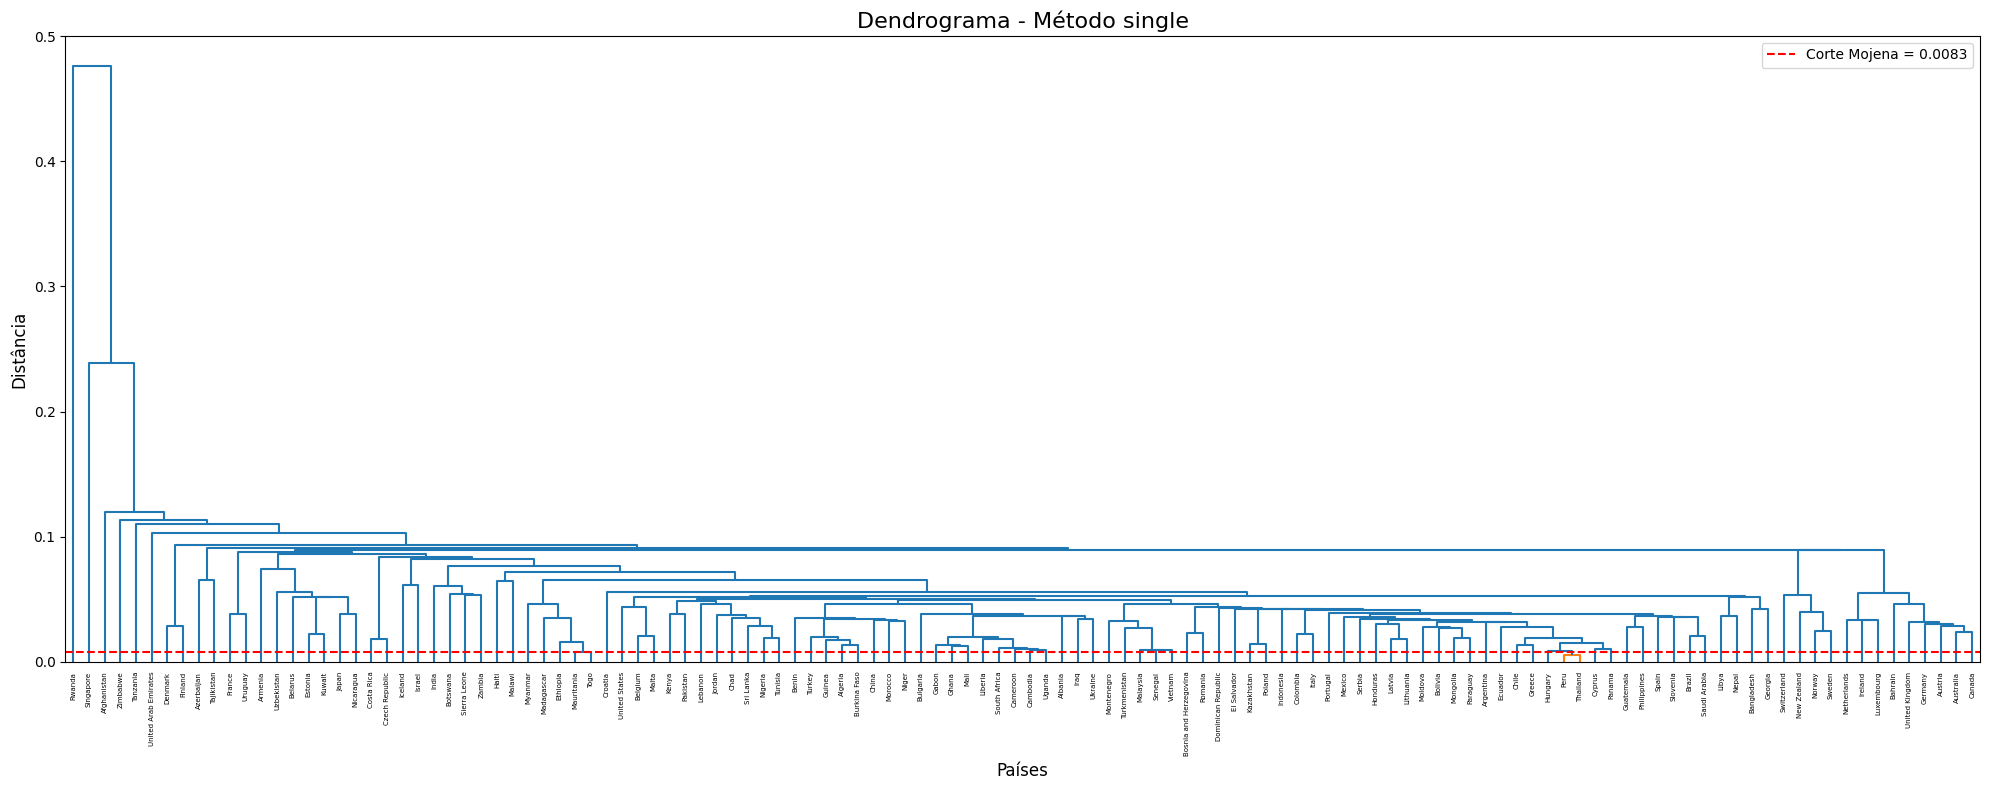

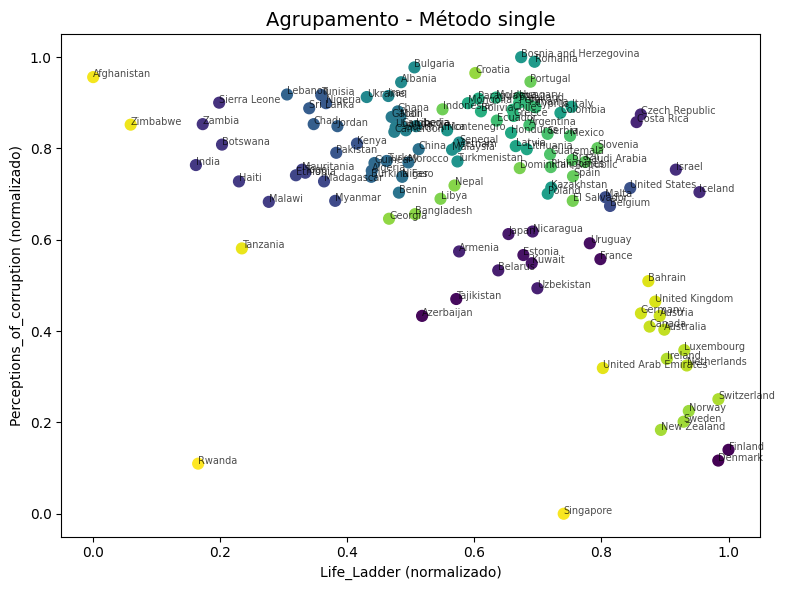


MÉTODO: COMPLETE
Número ótimo de clusters pelo método de Mojena: 121
Distância de corte estimada: 0.0083
Índice da quebra detectada: 1

Distribuição de países por cluster:
             País  Cluster
30        Denmark        1
36        Finland        2
84         Norway        3
103        Sweden        4
80    New Zealand        5
..            ...      ...
121      Zimbabwe      117
97   Sierra Leone      118
120        Zambia      119
15       Botswana      120
49          India      121

[122 rows x 2 columns]

Quantidade de países em cada cluster:
Cluster
1      1
2      1
3      1
4      1
5      1
      ..
117    1
118    1
119    1
120    1
121    1
Name: count, Length: 121, dtype: int64


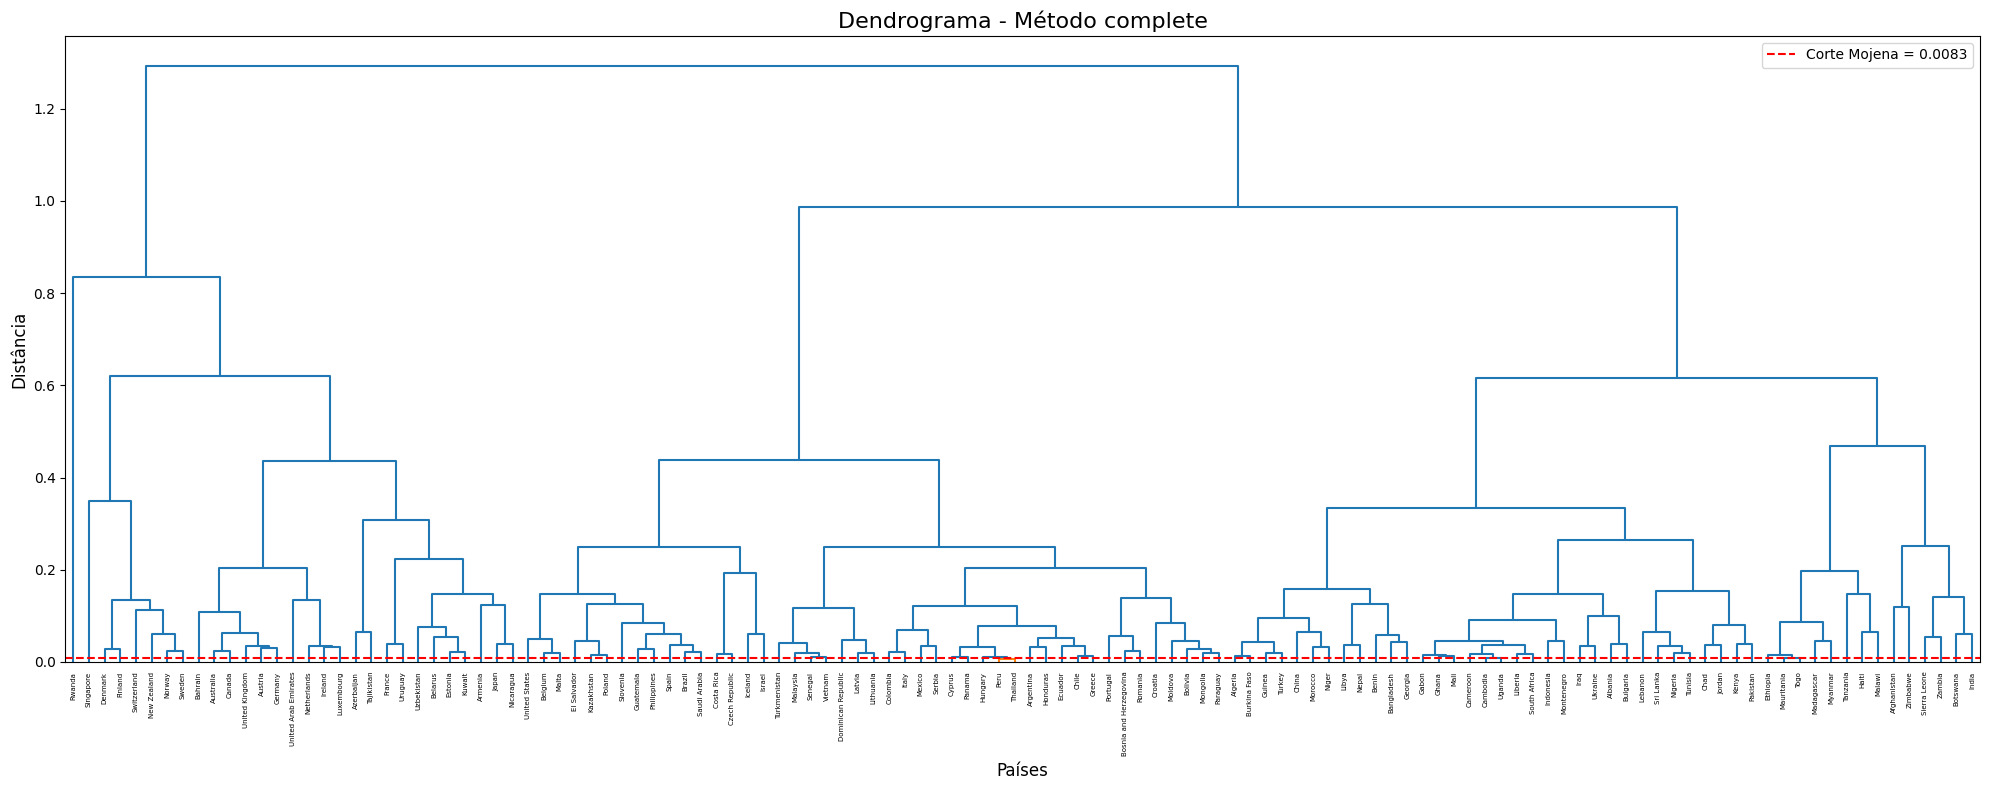

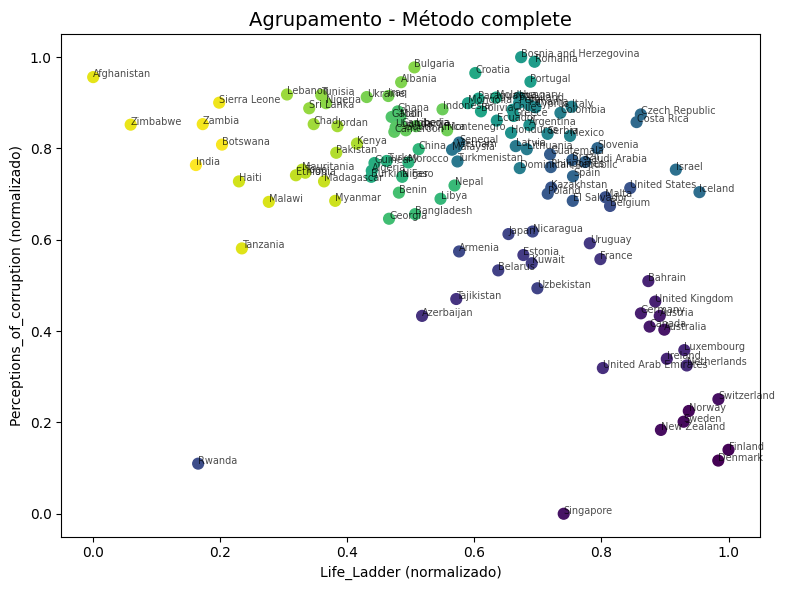


MÉTODO: WARD
Número ótimo de clusters pelo método de Mojena: 121
Distância de corte estimada: 0.0083
Índice da quebra detectada: 1

Distribuição de países por cluster:
               País  Cluster
5         Australia        1
21           Canada        2
6           Austria        3
40          Germany        4
115  United Kingdom        5
..              ...      ...
66       Madagascar      117
77          Myanmar      118
45            Haiti      119
67           Malawi      120
106        Tanzania      121

[122 rows x 2 columns]

Quantidade de países em cada cluster:
Cluster
1      1
2      1
3      1
4      1
5      1
      ..
117    1
118    1
119    1
120    1
121    1
Name: count, Length: 121, dtype: int64


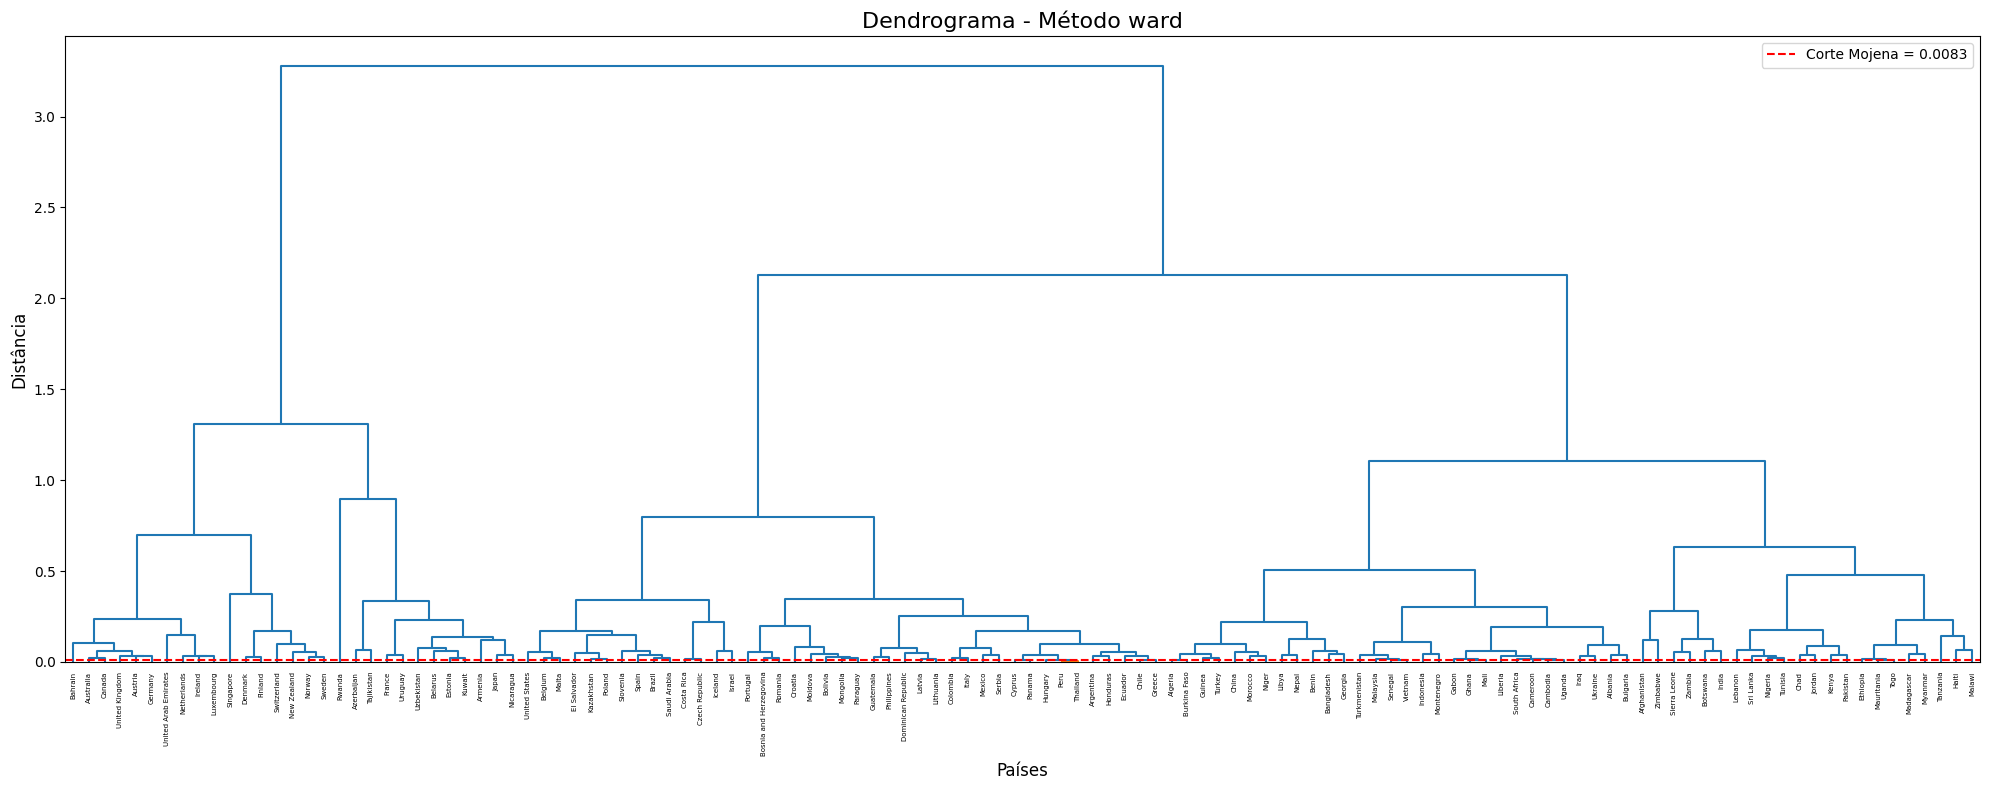

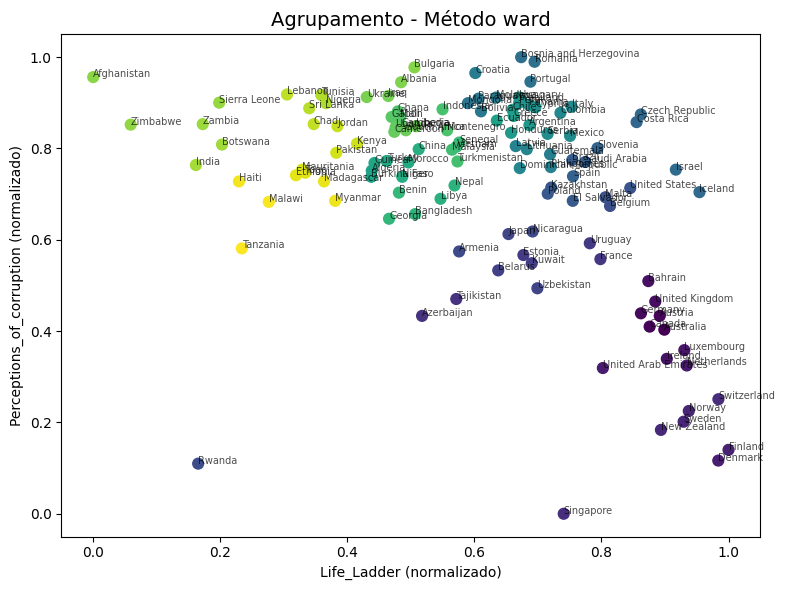

In [14]:
# ------------------------------------------------------------
# 8. Executa os três métodos pedidos para comparação
# ------------------------------------------------------------
res_single = analisar_metodo(Xs_numeric, Xs.index.tolist(), metodo='single', c_mojena=1.25)
res_complete = analisar_metodo(Xs_numeric, Xs.index.tolist(), metodo='complete', c_mojena=1.25)
res_ward = analisar_metodo(Xs_numeric, Xs.index.tolist(), metodo='ward', c_mojena=1.25)


In [15]:
# ------------------------------------------------------------
# 9. Tabela-resumo da comparação
# ------------------------------------------------------------
comparacao = pd.DataFrame({
    'Método': ['single', 'complete', 'ward'],
    'Número ótimo de clusters (Mojena)': [
        res_single['k_otimo'],
        res_complete['k_otimo'],
        res_ward['k_otimo']
    ],
    'Distância de corte': [
        res_single['corte'],
        res_complete['corte'],
        res_ward['corte']
    ]
})

print("\n" + "="*60)
print("COMPARAÇÃO FINAL DOS MÉTODOS")
print("="*60)
print(comparacao)


COMPARAÇÃO FINAL DOS MÉTODOS
     Método  Número ótimo de clusters (Mojena)  Distância de corte
0    single                                121            0.008263
1  complete                                121            0.008263
2      ward                                121            0.008263
